# Collaborative filtering on MovieLens

**Collaborative filtering** recommends items using only the behaviour of many users: people who agreed in the past tend to agree in the future. No information about the items themselves is needed.

On the MovieLens dataset (100,000 ratings of 9,700 movies by 610 users) this notebook implements, from scratch:

1. simple baselines (global mean, user and item biases);
2. **neighbourhood methods**: user-based and item-based k-nearest neighbours;
3. **matrix factorization** trained with stochastic gradient descent;

and evaluates them in two ways that tell surprisingly different stories: **rating prediction** (how close is the predicted rating?) and **top-N recommendation** (are the movies we recommend the ones the user actually watched and liked?).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
ratings = pd.read_csv("data/movielens/ratings.csv")
movies = pd.read_csv("data/movielens/movies.csv").set_index("movieId")
n_users, n_items = ratings["userId"].nunique(), ratings["movieId"].nunique()
print(f"{len(ratings):,} ratings, {n_users} users, {n_items:,} movies")
print(f"sparsity: {1 - len(ratings) / (n_users * n_items):.2%} of the user-movie matrix is empty")

100,836 ratings, 610 users, 9,724 movies
sparsity: 98.30% of the user-movie matrix is empty


## 1. The data

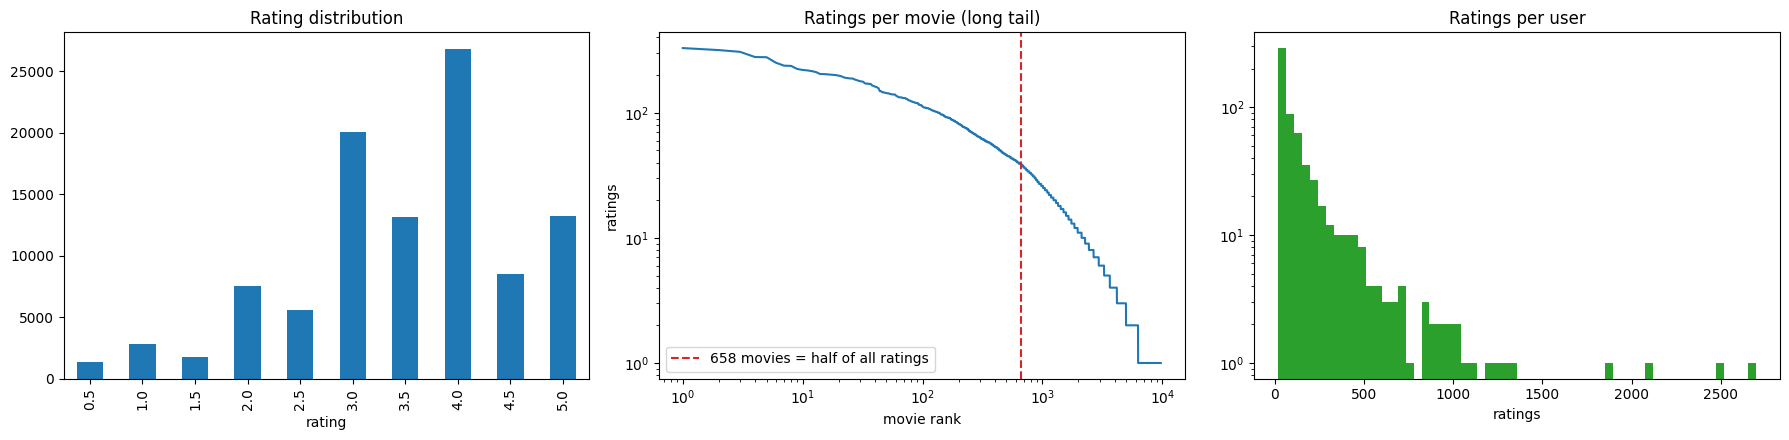

movies with a single rating: 3,446 (35%)
every user has at least 20 ratings; median 70


In [2]:
per_movie = ratings.groupby("movieId").size().sort_values(ascending=False)
per_user = ratings.groupby("userId").size()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
ratings["rating"].value_counts().sort_index().plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(title="Rating distribution", xlabel="rating")
axes[1].plot(np.arange(1, len(per_movie) + 1), per_movie.values)
axes[1].set(xscale="log", yscale="log", title="Ratings per movie (long tail)", xlabel="movie rank", ylabel="ratings")
share = per_movie.cumsum() / per_movie.sum()
top_share = (share <= 0.5).sum()
axes[1].axvline(top_share, color="tab:red", ls="--", label=f"{top_share} movies = half of all ratings")
axes[1].legend()
axes[2].hist(per_user, bins=60, color="tab:green")
axes[2].set(title="Ratings per user", xlabel="ratings", yscale="log")
fig.tight_layout()
plt.show()
print(f"movies with a single rating: {(per_movie == 1).sum():,} ({(per_movie == 1).mean():.0%})")
print(f"every user has at least {per_user.min()} ratings; median {per_user.median():.0f}")

- Ratings are skewed towards the positive side (4 stars is the most common rating): people mostly rate movies they chose to watch.
- The **long tail** is extreme: a few hundred popular movies collect half of all ratings, while 35% of the movies have been rated only once. Nothing reliable can be learned about them from ratings alone.
- Every user has rated at least 20 movies, but a few very active users have rated thousands.

## 2. A realistic train/test split

A random split would let the model learn from ratings given *after* the ones it has to predict. In deployment we always predict the future from the past, so we hold out, for every user, the **most recent 20%** of their ratings. Test ratings of movies that never appear in the training data cannot be handled by collaborative filtering and are dropped (we come back to this cold-start problem in the next notebook).

In [3]:
ratings = ratings.sort_values("timestamp")
position = ratings.groupby("userId").cumcount(ascending=False)
n_per_user = ratings.groupby("userId")["userId"].transform("size")
is_test = position < (0.2 * n_per_user).round()
train, test = ratings[~is_test].copy(), ratings[is_test].copy()
test = test[test["movieId"].isin(train["movieId"])]

users = np.sort(train["userId"].unique())
items = np.sort(train["movieId"].unique())
u_index = {u: i for i, u in enumerate(users)}
i_index = {m: i for i, m in enumerate(items)}
for df in (train, test):
    df["u"] = df["userId"].map(u_index)
    df["i"] = df["movieId"].map(i_index)

R = np.full((len(users), len(items)), np.nan, dtype=np.float32)
R[train["u"], train["i"]] = train["rating"]
print(f"train: {len(train):,} ratings, test: {len(test):,} ratings ({len(users)} users, {len(items):,} movies)")

train: 80,672 ratings, test: 18,471 ratings (610 users, 8,238 movies)


## 3. Rating prediction

We measure the **root mean squared error** (RMSE) between predicted and actual test ratings, on the 0.5–5 star scale.

### Baselines

The simplest predictor is the global mean. A much better one adds a **bias** per user (some people rate generously) and per item (some movies are liked by everybody):

$$\hat r_{ui} = \mu + b_u + b_i ,$$

estimated by alternating regularized averages: $b_i = \frac{\sum_{u}(r_{ui} - \mu - b_u)}{n_i + \lambda}$ and similarly for $b_u$. The regularization $\lambda$ shrinks the biases of items and users with few ratings towards zero.

In [4]:
def rmse(pred):
    return float(np.sqrt(np.mean((test["rating"].to_numpy() - pred) ** 2)))

mu = train["rating"].mean()
b_u, b_i = np.zeros(len(users)), np.zeros(len(items))
for _ in range(10):
    resid = train["rating"] - mu - b_u[train["u"]]
    b_i = np.bincount(train["i"], resid, len(items)) / (np.bincount(train["i"], minlength=len(items)) + 10)
    resid = train["rating"] - mu - b_i[train["i"]]
    b_u = np.bincount(train["u"], resid, len(users)) / (np.bincount(train["u"], minlength=len(users)) + 10)
baseline = lambda u, i: mu + b_u[u] + b_i[i]

results = {
    "global mean": rmse(np.full(len(test), mu)),
    "user + item biases": rmse(baseline(test["u"].to_numpy(), test["i"].to_numpy())),
}
pd.Series(results, name="test RMSE").round(4)

global mean           1.0571
user + item biases    0.8905
Name: test RMSE, dtype: float64

### Neighbourhood methods

**User-based kNN** predicts a rating from the ratings that the $k$ most similar users gave to the same movie. Similarity is the Pearson correlation of two users' ratings, computed as the cosine of their mean-centred rating vectors, so that a generous and a strict user can still agree:

$$\hat r_{ui} = \bar r_u + \frac{\sum_{v \in N_k(u, i)} s_{uv} (r_{vi} - \bar r_v)}{\sum_{v \in N_k(u, i)} |s_{uv}|}.$$

**Item-based kNN** does the same with movies: the predicted rating of movie $i$ is a weighted average of the user's own ratings of the $k$ movies most similar to $i$. Item similarities are usually more stable than user similarities, because each movie has many ratings and its "audience" changes slowly.

Similarities computed on very few co-ratings are unreliable, so they are shrunk towards zero by a factor $\frac{n_{common}}{n_{common} + 10}$.

In [5]:
def centred_cosine(M, axis_mean):
    """Shrunk cosine similarity between the rows of M after subtracting each row's mean."""
    observed = ~np.isnan(M)
    C = np.where(observed, M - axis_mean[:, None], 0).astype(np.float32)
    norms = np.sqrt((C ** 2).sum(1)) + 1e-9
    sim = (C @ C.T) / np.outer(norms, norms)
    common = observed.astype(np.float32) @ observed.T.astype(np.float32)
    sim *= common / (common + 10)
    np.fill_diagonal(sim, 0)
    return sim

def knn_predict(sim, M, means, rows, cols, k=30):
    """Predict M[row, col] from the k most similar rows that observed column col."""
    preds = np.empty(len(rows))
    for n, (a, c) in enumerate(zip(rows, cols)):
        candidates = np.where(~np.isnan(M[:, c]))[0]
        if len(candidates) == 0:
            preds[n] = means[a]
            continue
        s = sim[a, candidates]
        top = np.argsort(-s)[:k]
        s, neighbours = s[top], candidates[top]
        denom = np.abs(s).sum()
        preds[n] = means[a] + (s @ (M[neighbours, c] - means[neighbours]) / denom if denom > 0 else 0)
    return np.clip(preds, 0.5, 5)

start = time.time()
user_mean = np.nanmean(R, 1)
user_sim = centred_cosine(R, user_mean)
pred_user_knn = knn_predict(user_sim, R, user_mean, test["u"].to_numpy(), test["i"].to_numpy())
results["user-based kNN (k = 30)"] = rmse(pred_user_knn)

item_mean = mu + b_i                                   # shrunk item means (stable for rarely rated movies)
Rt = R.T
item_sim = centred_cosine(Rt, item_mean)
pred_item_knn = knn_predict(item_sim, Rt, item_mean, test["i"].to_numpy(), test["u"].to_numpy())
results["item-based kNN (k = 30)"] = rmse(pred_item_knn)
print(f"computed in {time.time() - start:.0f} s")
pd.Series(results, name="test RMSE").round(4)

computed in 1 s


global mean                1.0571
user + item biases         0.8905
user-based kNN (k = 30)    0.9165
item-based kNN (k = 30)    0.8684
Name: test RMSE, dtype: float64

### Matrix factorization

Matrix factorization assumes that tastes and movies can be described by a small number $f$ of latent factors (for example "how much action", "how mainstream"). Each user gets a vector $p_u$, each movie a vector $q_i$, and

$$\hat r_{ui} = \mu + b_u + b_i + p_u^\top q_i .$$

The parameters are learned by stochastic gradient descent on the squared error of the observed ratings, with L2 regularization $\lambda$ to avoid fitting the noise of users and movies with few ratings. This is the model popularized by the Netflix Prize.

30 epochs in 23 s


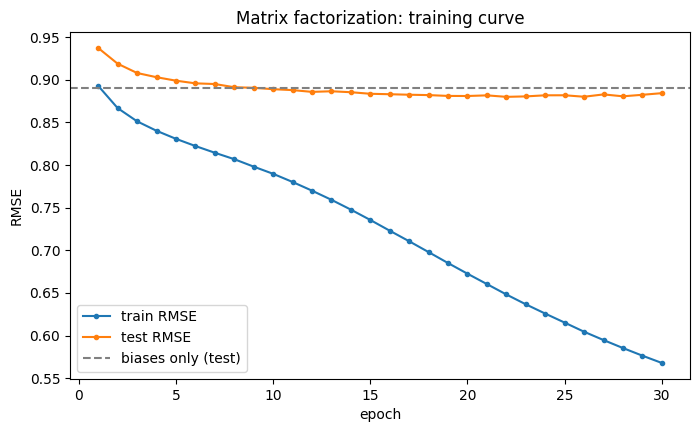

item-based kNN (k = 30)              0.8684
matrix factorization (30 factors)    0.8841
user + item biases                   0.8905
user-based kNN (k = 30)              0.9165
global mean                          1.0571
Name: test RMSE, dtype: float64

In [6]:
class MatrixFactorization:
    def __init__(self, n_users, n_items, factors=30, lr=0.01, reg=0.05, seed=0):
        rng = np.random.default_rng(seed)
        self.P = rng.normal(0, 0.1, (n_users, factors))
        self.Q = rng.normal(0, 0.1, (n_items, factors))
        self.bu, self.bi = np.zeros(n_users), np.zeros(n_items)
        self.lr, self.reg, self.rng = lr, reg, rng

    def fit_epoch(self, u, i, r, mu):
        for j in self.rng.permutation(len(r)):
            a, b = u[j], i[j]
            e = r[j] - (mu + self.bu[a] + self.bi[b] + self.P[a] @ self.Q[b])
            self.bu[a] += self.lr * (e - self.reg * self.bu[a])
            self.bi[b] += self.lr * (e - self.reg * self.bi[b])
            pa = self.P[a].copy()
            self.P[a] += self.lr * (e * self.Q[b] - self.reg * self.P[a])
            self.Q[b] += self.lr * (e * pa - self.reg * self.Q[b])

    def predict(self, u, i, mu):
        return mu + self.bu[u] + self.bi[i] + np.sum(self.P[u] * self.Q[i], axis=1)

mf = MatrixFactorization(len(users), len(items))
u_tr, i_tr, r_tr = train["u"].to_numpy(), train["i"].to_numpy(), train["rating"].to_numpy()
u_te, i_te = test["u"].to_numpy(), test["i"].to_numpy()
curve = []
start = time.time()
for epoch in range(1, 31):
    mf.fit_epoch(u_tr, i_tr, r_tr, mu)
    curve.append({"epoch": epoch, "train RMSE": np.sqrt(np.mean((r_tr - mf.predict(u_tr, i_tr, mu)) ** 2)),
                  "test RMSE": rmse(np.clip(mf.predict(u_te, i_te, mu), 0.5, 5))})
curve = pd.DataFrame(curve).set_index("epoch")
print(f"30 epochs in {time.time() - start:.0f} s")
results["matrix factorization (30 factors)"] = curve["test RMSE"].iloc[-1]

fig, ax = plt.subplots(figsize=(8, 4.5))
curve.plot(ax=ax, marker="o", ms=3)
ax.axhline(results["user + item biases"], color="grey", ls="--", label="biases only (test)")
ax.set(ylabel="RMSE", title="Matrix factorization: training curve")
ax.legend()
plt.show()
pd.Series(results, name="test RMSE").round(4).sort_values()

- The **biases** alone bring the RMSE from 1.06 to 0.89: most of the predictable variation in ratings comes from generous vs strict users and good vs bad movies.
- **Item-based kNN** is the most accurate model here (0.868), confirming that movie-to-movie similarities are more reliable than user-to-user ones.
- **User-based kNN** is even worse than the biases: with 610 users, the 30 nearest neighbours who rated a given movie are often not very similar, and their opinions add noise.
- **Matrix factorization** improves on the biases, but less than item-kNN. Its training curve shows the classic overfitting pattern: the training error keeps falling while the test error reaches its minimum around epoch 20 and then rises slightly. Stronger regularization or early stopping would help.

All the differences are small compared with the step from the global mean to the biases: in rating prediction the hard part is not the model, it is the noise in human ratings.

## 4. Top-N recommendation

In practice a recommender does not show predicted ratings; it shows a **short list**. What matters is whether the movies at the top of the list are ones the user wants. For every test user we rank all the movies they have not rated in the training period and take the top 10. A recommendation is a **hit** if the user rated that movie in the test period with at least 4 stars.

Metrics, averaged over users:

- **precision@10**: the share of the 10 recommendations that are hits;
- **recall@10**: the share of the user's relevant test movies that appear in the top 10;
- **NDCG@10**: like recall but rewarding hits near the top of the list;
- **coverage**: the share of the catalogue that is recommended to at least one user;
- **popularity**: the average number of training ratings of the recommended movies, a measure of how mainstream the recommendations are.

In [7]:
relevant = test[test["rating"] >= 4].groupby("u")["i"].apply(set)
eval_users = relevant.index.to_numpy()
seen = ~np.isnan(R)
popularity = np.bincount(train["i"], minlength=len(items))

def evaluate_topn(score_fn, k=10):
    precision, recall, ndcg, recommended, pop = [], [], [], set(), []
    discounts = 1 / np.log2(np.arange(2, k + 2))
    for u in eval_users:
        scores = score_fn(u).astype(float)
        scores[seen[u]] = -np.inf
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        hits = np.array([i in relevant[u] for i in top])
        precision.append(hits.mean())
        recall.append(hits.sum() / len(relevant[u]))
        ndcg.append((hits * discounts).sum() / discounts[:min(k, len(relevant[u]))].sum())
        recommended.update(top)
        pop.append(popularity[top].mean())
    return {"precision@10": np.mean(precision), "recall@10": np.mean(recall), "NDCG@10": np.mean(ndcg),
            "coverage": len(recommended) / len(items), "avg. popularity": np.mean(pop)}

rng = np.random.default_rng(0)
dense_item_sim = np.maximum(item_sim, 0)
binary = seen.astype(np.float32)
topn = {
    "random": evaluate_topn(lambda u: rng.random(len(items))),
    "most popular": evaluate_topn(lambda u: popularity),
    "biases (mu + b_u + b_i)": evaluate_topn(lambda u: b_i),
    "item-based kNN": evaluate_topn(lambda u: binary[u] @ dense_item_sim),
    "matrix factorization": evaluate_topn(lambda u: mf.predict(np.full(len(items), u), np.arange(len(items)), mu)),
}
topn = pd.DataFrame(topn).T
topn.round(3)

,precision@10,recall@10,NDCG@10,coverage,avg. popularity
random,0.003,0.003,0.003,0.515,9.077
most popular,0.057,0.050,0.075,0.012,216.120
biases (mu + b_u + b_i),0.043,0.033,0.052,0.007,132.776
item-based kNN,0.052,0.062,0.072,0.051,101.529
matrix factorization,0.021,0.016,0.025,0.058,47.494


The ranking evaluation turns the picture upside down:

- **Matrix factorization**, good at predicting ratings, is the worst model at ranking (precision 2%). Its top predicted ratings go to obscure movies with few, very positive ratings (average popularity 47 ratings), which the users rarely watch.
- The **most popular** movies, without any personalization, have the best precision (5.7%). Users do tend to watch the popular movies they have not seen yet, so popularity is a very hard baseline.
- **Item-based kNN** on the binary *who rated what* matrix has the best recall and an NDCG close to popularity, while recommending four times more of the catalogue and less mainstream movies. It is the best balance between accuracy and personalization.

All the absolute values are low: with thousands of candidate movies and a dozen relevant ones per user, finding them in a list of 10 is hard, and a movie the user did not watch in the test period is counted as a miss even if they would have liked it.

## 5. Recommendations for one user

In [8]:
typical = [u for u in eval_users if 50 <= seen[u].sum() <= 150]          # a user with a typical amount of history
u = int(max(typical, key=lambda u: len(relevant[u])))
history = train[train["u"] == u].sort_values("rating", ascending=False).head(8)
print(f"user {users[u]}: {seen[u].sum()} movies rated in the training period; favourites:")
print(history.assign(title=history["movieId"].map(movies["title"]))[["title", "rating"]].to_string(index=False))

def top_titles(scores, k=8):
    scores = scores.astype(float).copy()
    scores[seen[u]] = -np.inf
    top = np.argsort(-scores)[:k]
    return [("* " if i in relevant[u] else "  ") + movies.loc[items[i], "title"] for i in top]

pd.DataFrame({
    "most popular": top_titles(popularity),
    "item-based kNN": top_titles(binary[u] @ dense_item_sim),
    "matrix factorization": top_titles(mf.predict(np.full(len(items), u), np.arange(len(items)), mu)),
})

user 475: 124 movies rated in the training period; favourites:
                                                                                         title  rating
                                                                              Gladiator (2000)     5.0
                                                                             Spider-Man (2002)     5.0
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)     5.0
                                                                             District 9 (2009)     5.0
                                                                                  X-Men (2000)     5.0
                                                                                   Thor (2011)     5.0
                                                      Final Fantasy: The Spirits Within (2001)     5.0
                                            Howl's Moving Castle (Hauru no ugoku shiro) (2004)     5.0


,most popular,item-based kNN,matrix factorization
0,Forrest Gump (1994),Inception (2010),Guess Who's Coming to Dinner (1967)
1,"Shawshank Redemption, The (1994)",Iron Man 3 (2013),"Celebration, The (Festen) (1998)"
2,Pulp Fiction (1994),How to Train Your Dragon (2010),Bad Boy Bubby (1993)
3,"Silence of the Lambs, The (1991)",Up (2009),Rebecca (1940)
4,Braveheart (1995),"Day After Tomorrow, The (2004)","Shawshank Redemption, The (1994)"
5,Jurassic Park (1993),Star Trek Into Darkness (2013),It Happened One Night (1934)
6,Toy Story (1995),Rise of the Planet of the Apes (2011),"Last Detail, The (1973)"
7,* Terminator 2: Judgment Day (1991),Toy Story 3 (2010),Lawrence of Arabia (1962)


This user's favourites are recent blockbusters, superhero and fantasy movies. The three models answer very differently (movies the user actually rated 4+ in the test period are marked with *):

- **most popular** recommends the same 1990s classics to everyone, and happens to hit *Terminator 2*;
- **item-based kNN** proposes recent blockbusters and animated movies (Inception, Iron Man 3, Star Trek Into Darkness), which match the user's history much better, even though none of them was watched in the test period;
- **matrix factorization** recommends highly rated arthouse classics from the 1930s–60s, a typical symptom of ranking by predicted rating: they are predicted to be rated highly by anyone, but this user is unlikely to watch them.

## Summary

- MovieLens is **98% empty** and has a **long tail**: a few hundred movies receive half of all ratings.
- For **rating prediction**, user and item biases explain most of what can be explained; neighbourhood methods and matrix factorization add only a few hundredths of RMSE on top.
- For **top-N recommendation**, the ranking matters, not the predicted value. Models that are excellent at predicting ratings can be poor at ranking, and a simple **popularity** list is a hard baseline. Item-based kNN on *who watched what* captures personal taste better.
- Always evaluate with a **temporal split** and with metrics that match how the system is used, and track **coverage** and **popularity** to see whether the recommender only promotes blockbusters.